# # 🤖 Sistema ML Multi-Target - Predicción WaterTank por Provincia
# **Modelos:** LinearRegression, RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
# **Entrena modelos por provincia y magnitud para integración MCP**

In [11]:
# ============= IMPORTS =============
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional
import json
from collections import defaultdict

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Setup completado")


✅ Setup completado


In [12]:
# ============= CONFIGURACIÓN =============
# DATA_PATH = Path("../data/watertank_processed.csv")
DATA_PATH = Path("../data/processed/watertanktop.csv")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True, parents=True)

# Variables objetivo a predecir (adaptadas a las columnas reales del dataset)
TARGET_CONFIGS = {
    'watertanklevel': {
        'name': 'Nivel tanque',
        'unit': 'cm',
        'range': [0, 500],
        'priority': 1
    },
    'clexitlevel': {
        'name': 'Cloro salida',
        'unit': 'ppm',
        'range': [0, 2],
        'priority': 2
    },
    'phexitlevel': {
        'name': 'pH salida',
        'unit': '-',
        'range': [0, 14],
        'priority': 3
    },
    'waterturbidityexitlevel': {
        'name': 'Turbidez salida',
        'unit': 'NTU',
        'range': [0, 5000],
        'priority': 4
    },
    'temperature': {
        'name': 'Temperatura',
        'unit': '°C',
        'range': [0, 50],
        'priority': 5
    },
    'pressurelevel': {
        'name': 'Presión',
        'unit': 'bar',
        'range': [0, 5],
        'priority': 6
    },
    'orpexitlevel': {
        'name': 'ORP salida',
        'unit': 'mV',
        'range': [0, 1000],
        'priority': 7
    },
    'flowexitlevel': {
        'name': 'Flujo salida',
        'unit': 'm³/h',
        'range': [0, 100],
        'priority': 8
    },
    'cltanklevel': {
        'name': 'Cloro tanque',
        'unit': 'ppm',
        'range': [0, 2],
        'priority': 9
    },
    'clinjector': {
        'name': 'Cloro inyector',
        'unit': 'ppm',
        'range': [0, 2],
        'priority': 10
    },
    'waterleavingtanks': {
        'name': 'Agua salida',
        'unit': 'm³',
        'range': [0, 10000],
        'priority': 11
    }
}

In [13]:
# Configuración de modelos
MODELS = {
    'LinearRegression': (LinearRegression(), True),
    'RandomForest': (RandomForestRegressor(
        n_estimators=100, max_depth=15, min_samples_split=10,
        n_jobs=15, random_state=42
    ), False),
    'GradientBoosting': (GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=5,
        random_state=42
    ), False),
    'HistGradientBoosting': (HistGradientBoostingRegressor(
        max_iter=100, learning_rate=0.1, max_depth=8,
        random_state=42
    ), False)
}

# Umbrales de muestras
MIN_SAMPLES_PROVINCE = 500      # Mínimo para entrenar modelo provincial
MIN_SAMPLES_TANK = 100          # Mínimo para entrenar modelo por tanque
MIN_SAMPLES_SPLIT = 50          # Mínimo para hacer train/test split
MIN_SAMPLES_CLUSTER = 200       # Mínimo para clusterización

# Configuración de clusterización
CLUSTER_FEATURES = [
    'watertanklevel', 'clexitlevel', 'phexitlevel', 'temperature',
    'pressurelevel', 'flowexitlevel', 'orpexitlevel'
]
N_CLUSTERS = 3  # Número de clusters por defecto

print(f"📊 Configuración cargada:")
print(f"  • Targets: {len(TARGET_CONFIGS)}")
print(f"  • Modelos: {len(MODELS)}")
print(f"  • Min muestras provincia: {MIN_SAMPLES_PROVINCE}")
print(f"  • Min muestras tanque: {MIN_SAMPLES_TANK}")
print(f"  • Clusterización: {N_CLUSTERS} clusters")

📊 Configuración cargada:
  • Targets: 11
  • Modelos: 4
  • Min muestras provincia: 500
  • Min muestras tanque: 100
  • Clusterización: 3 clusters


In [14]:
# ============= FUNCIÓN DE CLUSTERIZACIÓN =============
# Agrupa tanques por comportamiento
# Usa KMeans para crear clusters
# PCA para visualización 2D
# Calcula estadísticas por cluster
def perform_clustering(df_subset: pd.DataFrame, province: str, n_clusters: int = N_CLUSTERS) -> Dict:
    """
    Realiza clusterización de tanques por comportamiento
    
    Args:
        df_subset: DataFrame filtrado por provincia
        province: Nombre de la provincia
        n_clusters: Número de clusters
    
    Returns:
        Dict con modelo, labels y estadísticas
    """
    # Preparar datos para clustering
    cluster_features_available = [f for f in CLUSTER_FEATURES if f in df_subset.columns]
    
    if len(cluster_features_available) < 3:
        return {'status': 'insufficient_features', 'province': province}
    
    # Agregar por tanque (promedios)
    tank_profiles = df_subset.groupby('entityid')[cluster_features_available].agg(['mean', 'std']).reset_index()
    tank_profiles.columns = ['_'.join(col).strip('_') for col in tank_profiles.columns]
    tank_profiles = tank_profiles.dropna()
    
    if len(tank_profiles) < n_clusters:
        return {'status': 'insufficient_tanks', 'province': province, 'n_tanks': len(tank_profiles)}
    
    # Escalar features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(tank_profiles.iloc[:, 1:])  # Excluir entityid
    
    # K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # PCA para visualización
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Estadísticas por cluster
    tank_profiles['cluster'] = cluster_labels
    tank_profiles['pca1'] = X_pca[:, 0]
    tank_profiles['pca2'] = X_pca[:, 1]
    
    cluster_stats = {}
    for i in range(n_clusters):
        cluster_data = tank_profiles[tank_profiles['cluster'] == i]
        cluster_stats[f'cluster_{i}'] = {
            'n_tanks': len(cluster_data),
            'tank_ids': cluster_data['entityid'].tolist()
        }
    
    return {
        'status': 'success',
        'province': province,
        'n_clusters': n_clusters,
        'n_tanks': len(tank_profiles),
        'kmeans_model': kmeans,
        'scaler': scaler,
        'pca_model': pca,
        'cluster_labels': cluster_labels,
        'tank_profiles': tank_profiles,
        'cluster_stats': cluster_stats,
        'features_used': cluster_features_available,
        'inertia': kmeans.inertia_,
        'silhouette_score': None  # Se puede calcular si se necesita
    }

In [15]:
# ============= CARGA Y ANÁLISIS DE DATOS =============
df = pd.read_csv(DATA_PATH)
#df['timeinstant'] = pd.to_datetime(df['timeinstant'])
df['timeinstant'] = pd.to_datetime(df['timeinstant'], format='ISO8601')

print(f"\n✅ Datos cargados: {df.shape[0]:,} × {df.shape[1]}")
print(f"📍 Provincias: {df['province'].nunique()}")
print(f"🏭 Tanques: {df['entityid'].nunique()}")

# Análisis detallado
province_tank_analysis = df.groupby(['province', 'entityid']).size().reset_index(name='records')
province_summary = province_tank_analysis.groupby('province').agg({
    'entityid': 'count',
    'records': ['sum', 'mean', 'min', 'max']
}).round(0)
province_summary.columns = ['n_tanks', 'total_records', 'avg_records_per_tank', 'min_records', 'max_records']

print(f"\n📊 Análisis por provincia:")
display(province_summary)


✅ Datos cargados: 16,106,666 × 29
📍 Provincias: 6
🏭 Tanques: 99

📊 Análisis por provincia:


,n_tanks,total_records,avg_records_per_tank,min_records,max_records
province,,,,,
Burgos,6,44649,7442.0,966,8799
Palencia,21,14629892,696662.0,440,6287745
Salamanca,44,358472,8147.0,3209,10725
Soria,14,342684,24477.0,11150,30032
Valladolid,4,32702,8176.0,8171,8184
Ávila,1,676922,676922.0,676922,676922


In [16]:
# ============= PREPARACIÓN DE FEATURES =============
def prepare_features(data: pd.DataFrame, target: str) -> Tuple[pd.DataFrame, List[str]]:
    """Prepara features excluyendo targets y columnas no numéricas"""
    # Columnas disponibles en el dataset
    available_targets = [
        'clexitlevel', 'clinjector', 'cltanklevel', 'phexitlevel',
        'waterleavingtanks', 'watertanklevel', 'waterturbidityexitlevel',
        'orpexitlevel', 'soiling', 'rssi', 'temperature', 'nasensor',
        'calibration', 'flowexitlevel', 'pressurelevel', 'clslope', 'clgross',
        'pressureexitlevel', 'temperatureexitlevel', 'turbidityentrylevel'
    ]
    
    exclude_cols = ['timeinstant', 'entityid', 'province'] + available_targets
    
    # Seleccionar solo columnas numéricas
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    feature_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    # Filtrar features con varianza
    feature_cols = [
        col for col in feature_cols 
        if data[col].nunique() > 1 and data[col].notna().sum() > 50
    ]
    
    return data[feature_cols].copy(), feature_cols

In [17]:
# ============= FUNCIÓN DE EVALUACIÓN DE MODELO =============
def evaluate_model(
    model, X_train, X_test, y_train, y_test, 
    model_name: str, use_scaling: bool
) -> Dict:
    """Entrena y evalúa un modelo"""
    # Escalar si es necesario
    if use_scaling:
        scaler = StandardScaler()
        X_train_proc = scaler.fit_transform(X_train)
        X_test_proc = scaler.transform(X_test)
    else:
        scaler = None
        X_train_proc = X_train
        X_test_proc = X_test
    
    # Entrenar
    model.fit(X_train_proc, y_train)
    
    # Predecir
    y_train_pred = model.predict(X_train_proc)
    y_test_pred = model.predict(X_test_proc)
    
    # Métricas
    metrics = {
        'model_name': model_name,
        'train_r2': r2_score(y_train, y_train_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'train_mae': mean_absolute_error(y_train, y_train_pred),
        'test_mae': mean_absolute_error(y_test, y_test_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'use_scaling': use_scaling
    }
    
    return metrics, model, scaler

In [18]:
# ============= ENTRENAMIENTO UNIFICADO =============
def train_model(
    df_subset: pd.DataFrame,
    target: str,
    feature_cols: List[str],
    scope_type: str,  # 'province' o 'tank'
    scope_id: str,
    province: str,
    tank_id: Optional[str] = None
) -> Dict:
    """Función unificada para entrenar modelo (provincia o tanque)"""
    
    # Preparar X e y
    X = df_subset[feature_cols].copy()
    y = df_subset[target].copy()
    
    # Eliminar NaN en target
    mask = y.notna()
    X = X[mask]
    y = y[mask]
    
    if len(X) < MIN_SAMPLES_SPLIT:
        return {
            'status': 'insufficient_data',
            'n_samples': len(X),
            'scope_type': scope_type,
            'province': province,
            'tank_id': tank_id,
            'target': target
        }
    
    # Imputar missing en features
    if X.isnull().sum().sum() > 0:
        X = X.fillna(X.median())
    
    # Split
    try:
        test_size = min(0.2, max(0.1, 20 / len(X)))  # Adaptativo
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, shuffle=True
        )
    except ValueError:
        return {
            'status': 'split_error',
            'n_samples': len(X),
            'scope_type': scope_type,
            'province': province,
            'tank_id': tank_id,
            'target': target
        }
    
    # Entrenar todos los modelos
    results = []
    best_model = None
    best_scaler = None
    best_r2 = -np.inf
    
    for model_name, (model, use_scaling) in MODELS.items():
        try:
            metrics, trained_model, scaler = evaluate_model(
                model, X_train, X_test, y_train, y_test,
                model_name, use_scaling
            )
            results.append(metrics)
            
            if metrics['test_r2'] > best_r2:
                best_r2 = metrics['test_r2']
                best_model = trained_model
                best_scaler = scaler
                best_model_name = model_name
                best_use_scaling = use_scaling
        except Exception as e:
            continue
    
    if not results:
        return {
            'status': 'training_error',
            'scope_type': scope_type,
            'province': province,
            'tank_id': tank_id,
            'target': target
        }
    
    # Validación cruzada del mejor modelo
    try:
        X_cv = X_train if not best_use_scaling else StandardScaler().fit_transform(X_train)
        n_folds = min(5, len(X_train) // 20)
        cv_scores = cross_val_score(
            best_model, X_cv, y_train, cv=max(2, n_folds),
            scoring='r2', n_jobs=15
        )
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
    except:
        cv_mean = best_r2
        cv_std = 0
    
    return {
        'status': 'success',
        'scope_type': scope_type,
        'province': province,
        'tank_id': tank_id,
        'target': target,
        'best_model_name': best_model_name,
        'best_model': best_model,
        'best_scaler': best_scaler,
        'use_scaling': best_use_scaling,
        'feature_cols': feature_cols,
        'n_samples': len(X),
        'n_train': len(X_train),
        'n_test': len(X_test),
        'test_r2': best_r2,
        'test_mae': [m for m in results if m['model_name'] == best_model_name][0]['test_mae'],
        'test_rmse': [m for m in results if m['model_name'] == best_model_name][0]['test_rmse'],
        'cv_mean_r2': cv_mean,
        'cv_std_r2': cv_std,
        'all_results': results
    }

In [19]:
# ============= ENTRENAMIENTO MASIVO =============
print("\n" + "="*80)
print("🚀 INICIANDO ENTRENAMIENTO MASIVO (PROVINCIA + TANQUE)")
print("="*80)

# Preparar features
X_all, feature_cols = prepare_features(df, 'watertanklevel')

print(f"\n📊 Features preparadas: {len(feature_cols)}")
print(f"   Primeras 10: {', '.join(feature_cols[:10])}...")

# Identificar provincias y tanques válidos
provinces_data = df.groupby('province').size()
valid_provinces = provinces_data[provinces_data >= MIN_SAMPLES_PROVINCE].index.tolist()

tanks_by_province = defaultdict(list)
for province in valid_provinces:
    tanks = df[df['province'] == province].groupby('entityid').size()
    valid_tanks = tanks[tanks >= MIN_SAMPLES_TANK].index.tolist()
    tanks_by_province[province] = valid_tanks

print(f"\n📍 Provincias válidas: {len(valid_provinces)}")
print(f"🏭 Tanques válidos totales: {sum(len(v) for v in tanks_by_province.values())}")

# Estructuras para resultados
all_results = defaultdict(dict)
training_summary = []


🚀 INICIANDO ENTRENAMIENTO MASIVO (PROVINCIA + TANQUE)

📊 Features preparadas: 2
   Primeras 10: year, month...

📍 Provincias válidas: 6
🏭 Tanques válidos totales: 90


In [20]:
# ============= ENTRENAR POR PROVINCIA =============
for province in valid_provinces:
    print(f"\n{'='*80}")
    print(f"📍 PROVINCIA: {province}")
    print(f"{'='*80}")
    
    province_models = {}
    
    for target, config in TARGET_CONFIGS.items():
        # Verificar datos disponibles
        df_prov = df[df['province'] == province]
        n_valid = df_prov[target].notna().sum()
        
        if n_valid < MIN_SAMPLES_SPLIT:
            continue
        
        print(f"\n  🎯 [{province}] Target: {config['name']} ({n_valid} registros)")
        
        # Entrenar modelo provincial
        result = train_model(
            df_prov, target, feature_cols,
            scope_type='province',
            scope_id=province,
            province=province
        )
        
        if result['status'] == 'success':
            print(f"    ✅ Modelo provincial: {result['best_model_name']}")
            print(f"       R²: {result['test_r2']:.4f} | MAE: {result['test_mae']:.4f}")
            
            # Guardar modelo provincial
            model_dir = MODELS_DIR / province / "province"
            model_dir.mkdir(exist_ok=True, parents=True)
            
            model_path = model_dir / f"{result['best_model_name'].lower().replace(' ', '_')}_{target}.pkl"
            joblib.dump(result['best_model'], model_path)
            
            if result['best_scaler']:
                scaler_path = model_dir / f"scaler_{target}.pkl"
                joblib.dump(result['best_scaler'], scaler_path)
            
            # Metadata provincial
            metadata = {
                'scope_type': 'province',
                'province': province,
                'tank_id': None,
                'target': target,
                'target_name': config['name'],
                'target_unit': config['unit'],
                'model_name': result['best_model_name'],
                'features': feature_cols,
                'n_features': len(feature_cols),
                'test_r2': float(result['test_r2']),
                'test_mae': float(result['test_mae']),
                'test_rmse': float(result['test_rmse']),
                'cv_mean_r2': float(result['cv_mean_r2']),
                'cv_std_r2': float(result['cv_std_r2']),
                'n_train': result['n_train'],
                'n_test': result['n_test'],
                'use_scaling': result['use_scaling'],
                'trained_on': datetime.now().isoformat(),
                'model_path': str(model_path),
                'scaler_path': str(model_dir / f"scaler_{target}.pkl") if result['best_scaler'] else None
            }
            
            metadata_path = model_dir / f"metadata_{target}.json"
            with open(metadata_path, 'w') as f:
                json.dump(metadata, f, indent=2)
            
            province_models[target] = result
            training_summary.append(metadata)
    
    all_results[province]['province'] = province_models


📍 PROVINCIA: Burgos

  🎯 [Burgos] Target: Nivel tanque (44649 registros)
    ✅ Modelo provincial: GradientBoosting
       R²: 0.0717 | MAE: 22.9890

  🎯 [Burgos] Target: Cloro salida (44649 registros)
    ✅ Modelo provincial: LinearRegression
       R²: 0.0001 | MAE: 0.0952

  🎯 [Burgos] Target: pH salida (44649 registros)
    ✅ Modelo provincial: LinearRegression
       R²: -0.0002 | MAE: 0.1918

  🎯 [Burgos] Target: Turbidez salida (44649 registros)
    ✅ Modelo provincial: LinearRegression
       R²: -0.0003 | MAE: 140.3568

  🎯 [Burgos] Target: Temperatura (44649 registros)
    ✅ Modelo provincial: LinearRegression
       R²: -0.0001 | MAE: 11.3961

  🎯 [Burgos] Target: Presión (44649 registros)
    ✅ Modelo provincial: LinearRegression
       R²: -0.0001 | MAE: 1.3276

  🎯 [Burgos] Target: ORP salida (44649 registros)
    ✅ Modelo provincial: LinearRegression
       R²: -0.0003 | MAE: 19.5139

  🎯 [Burgos] Target: Flujo salida (44649 registros)
    ✅ Modelo provincial: LinearRegr

In [21]:
# ============= ENTRENAR POR TANQUE =============
print(f"\n{'='*80}")
print("🏭 ENTRENANDO MODELOS POR TANQUE")
print(f"{'='*80}")

tank_training_count = 0

for province, tanks in tanks_by_province.items():
    if not tanks:
        continue
    
    print(f"\n📍 {province}: {len(tanks)} tanques")
    
    for tank_id in tanks:
        df_tank = df[(df['province'] == province) & (df['entityid'] == tank_id)]
        
        tank_models = {}
        
        for target, config in TARGET_CONFIGS.items():
            n_valid = df_tank[target].notna().sum()
            
            if n_valid < MIN_SAMPLES_SPLIT:
                continue
            
            result = train_model(
                df_tank, target, feature_cols,
                scope_type='tank',
                scope_id=tank_id,
                province=province,
                tank_id=tank_id
            )
            
            if result['status'] == 'success':
                # Guardar modelo de tanque
                model_dir = MODELS_DIR / province / "tanks" / tank_id
                model_dir.mkdir(exist_ok=True, parents=True)
                
                model_path = model_dir / f"{result['best_model_name'].lower().replace(' ', '_')}_{target}.pkl"
                joblib.dump(result['best_model'], model_path)
                
                if result['best_scaler']:
                    scaler_path = model_dir / f"scaler_{target}.pkl"
                    joblib.dump(result['best_scaler'], scaler_path)
                
                # Metadata de tanque
                metadata = {
                    'scope_type': 'tank',
                    'province': province,
                    'tank_id': tank_id,
                    'target': target,
                    'target_name': config['name'],
                    'target_unit': config['unit'],
                    'model_name': result['best_model_name'],
                    'features': feature_cols,
                    'n_features': len(feature_cols),
                    'test_r2': float(result['test_r2']),
                    'test_mae': float(result['test_mae']),
                    'test_rmse': float(result['test_rmse']),
                    'cv_mean_r2': float(result['cv_mean_r2']),
                    'cv_std_r2': float(result['cv_std_r2']),
                    'n_train': result['n_train'],
                    'n_test': result['n_test'],
                    'use_scaling': result['use_scaling'],
                    'trained_on': datetime.now().isoformat(),
                    'model_path': str(model_path),
                    'scaler_path': str(model_dir / f"scaler_{target}.pkl") if result['best_scaler'] else None
                }
                
                metadata_path = model_dir / f"metadata_{target}.json"
                with open(metadata_path, 'w') as f:
                    json.dump(metadata, f, indent=2)
                
                tank_models[target] = result
                training_summary.append(metadata)
                tank_training_count += 1
        
        if tank_models:
            if 'tanks' not in all_results[province]:
                all_results[province]['tanks'] = {}
            all_results[province]['tanks'][tank_id] = tank_models
            print(f"    ✅ {tank_id}: {len(tank_models)} targets")

print(f"\n✅ Modelos de tanque entrenados: {tank_training_count}")


🏭 ENTRENANDO MODELOS POR TANQUE

📍 Burgos: 6 tanques
    ✅ BU_BARON_AGU_0001: 11 targets
    ✅ BU_FRERT_AGU_0001: 11 targets
    ✅ BU_FRIAS_AGU_0001: 11 targets
    ✅ BU_NAVBU_AGU_0001: 11 targets
    ✅ BU_SANOB_AGU_0001: 11 targets
    ✅ BU_SAPGA_AGU_0001: 11 targets

📍 Palencia: 21 tanques
    ✅ PA_BOACA_AGU_0001: 11 targets
    ✅ PA_CARCO_AGU_0001: 11 targets
    ✅ PA_CARCO_AGU_0002: 11 targets
    ✅ PA_CARCO_AGU_0003: 11 targets
    ✅ PA_CERVA_AGU_0001: 11 targets
    ✅ PA_FROMI_AGU_0001: 11 targets
    ✅ PA_FROMI_AGU_0002: 11 targets
    ✅ PA_FROMI_AGU_0003: 11 targets
    ✅ PA_ITEVE_AGU_0001: 11 targets
    ✅ PA_LAGAR_AGU_0001: 11 targets
    ✅ PA_LEDIG_AGU_0001: 11 targets
    ✅ PA_MORAT_AGU_0001: 11 targets
    ✅ PA_MORAT_AGU_0002: 11 targets
    ✅ PA_POBCA_AGU_0001: 11 targets
    ✅ PA_REVCA_AGU_0001: 11 targets
    ✅ PA_SANMA_AGU_0001: 11 targets
    ✅ PA_SANTO_AGU_0001: 11 targets
    ✅ PA_TAMCA_AGU_0001: 11 targets
    ✅ PA_VIECO_AGU_0001: 11 targets
    ✅ PA_VIERO_AGU_000


🎯 CLUSTERIZACIÓN DE TANQUES POR PROVINCIA

📍 Burgos: Clustering 6 tanques...
  ✅ 3 clusters creados
  📊 Distribución:
     • cluster_0: 4 tanques
     • cluster_1: 1 tanques
     • cluster_2: 1 tanques


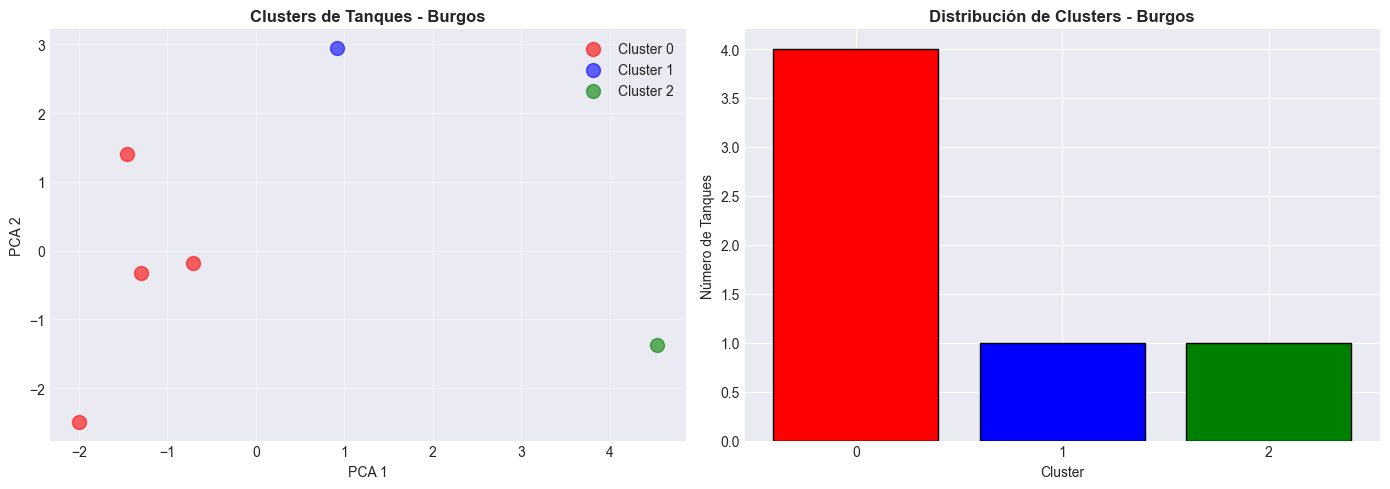


📍 Palencia: Clustering 21 tanques...
  ✅ 3 clusters creados
  📊 Distribución:
     • cluster_0: 19 tanques
     • cluster_1: 1 tanques
     • cluster_2: 1 tanques


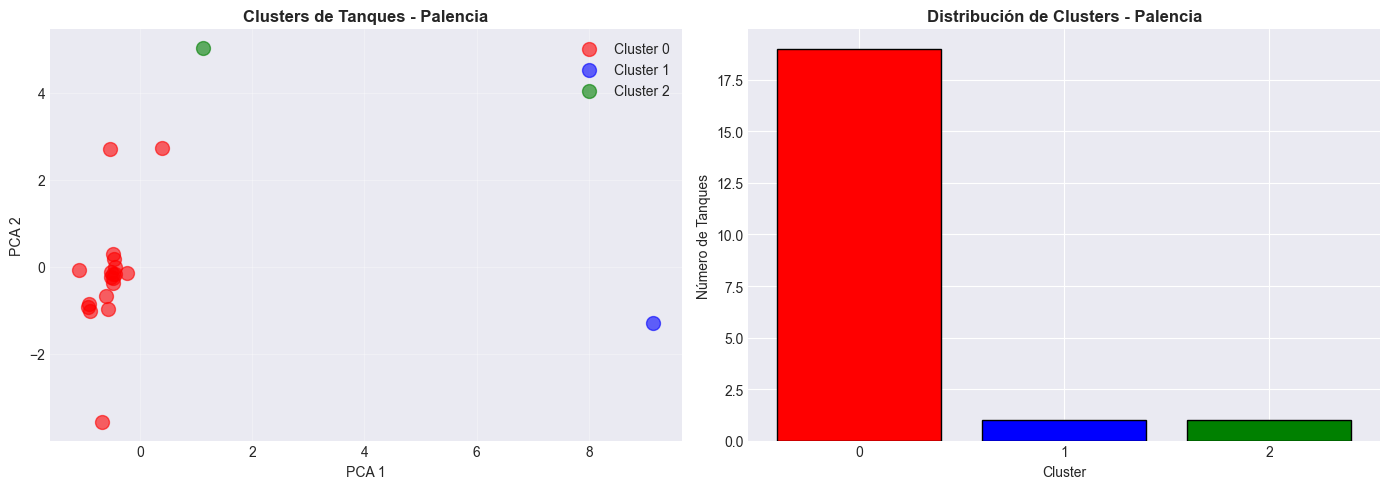


📍 Salamanca: Clustering 44 tanques...
  ✅ 3 clusters creados
  📊 Distribución:
     • cluster_0: 13 tanques
     • cluster_1: 18 tanques
     • cluster_2: 13 tanques


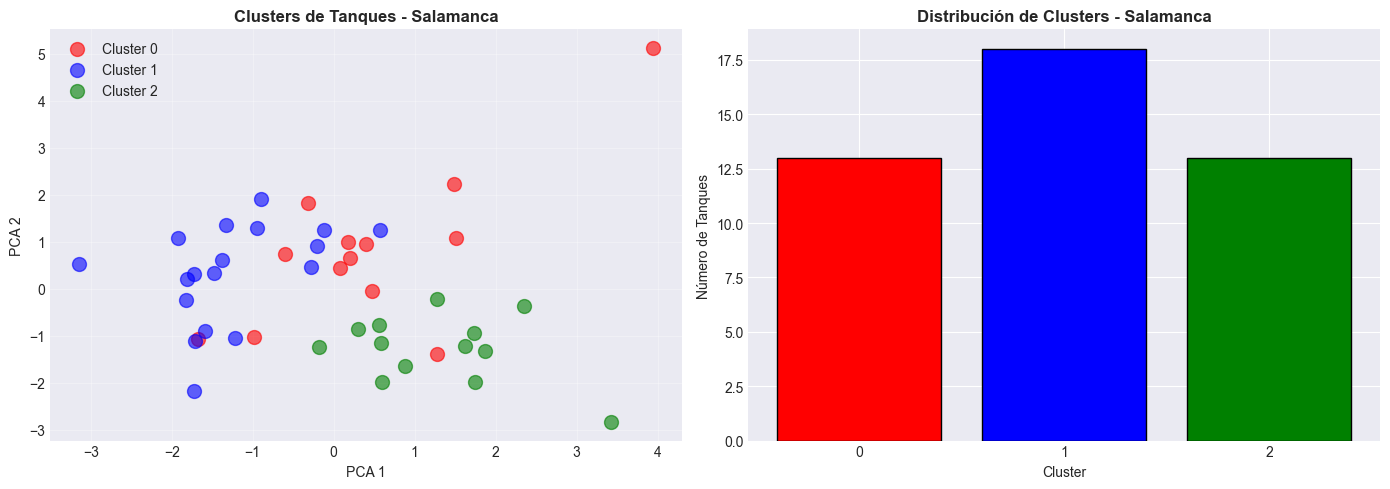


📍 Soria: Clustering 14 tanques...
  ✅ 3 clusters creados
  📊 Distribución:
     • cluster_0: 5 tanques
     • cluster_1: 6 tanques
     • cluster_2: 3 tanques


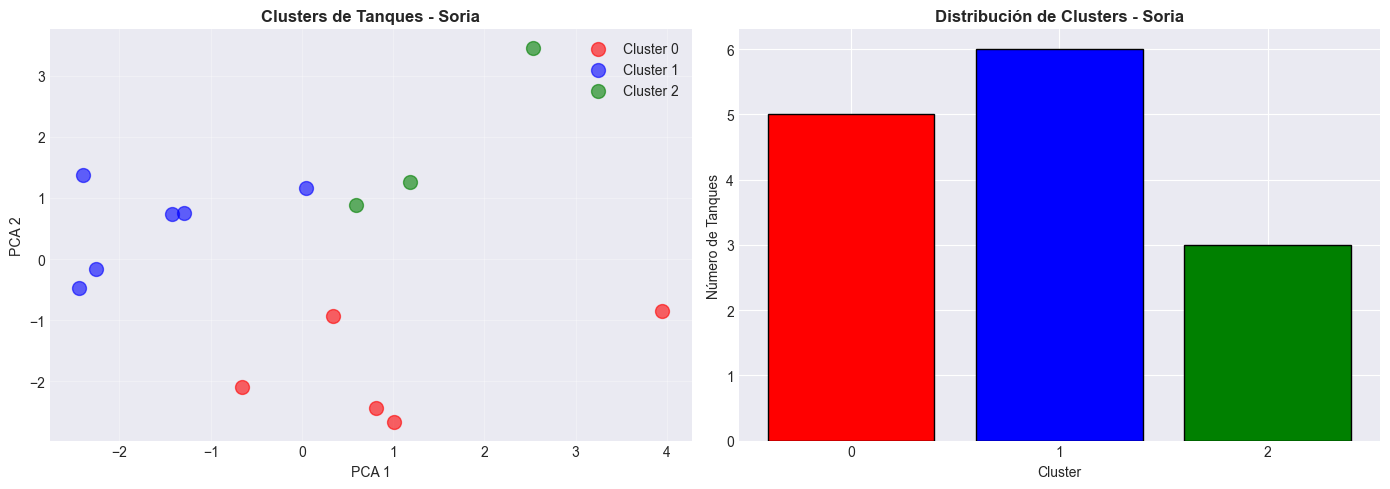


📍 Valladolid: Clustering 4 tanques...
  ✅ 3 clusters creados
  📊 Distribución:
     • cluster_0: 1 tanques
     • cluster_1: 2 tanques
     • cluster_2: 1 tanques


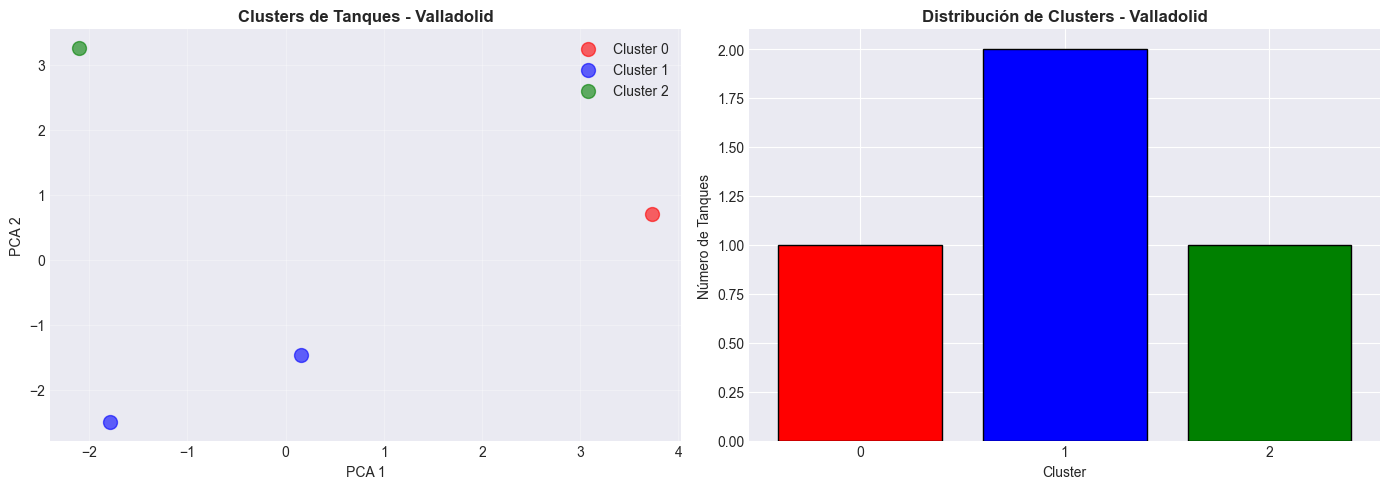


📍 Ávila: Insuficientes tanques (1)

✅ Clusterización completada: 5 provincias


In [22]:
# ============= CLUSTERIZACIÓN POR PROVINCIA =============
# - Ejecuta clustering para cada provincia
# - Guarda modelos (KMeans, Scaler, PCA)
# - Genera visualizaciones
# - Guarda asignaciones tanque→cluster en CSV
print(f"\n{'='*80}")
print("🎯 CLUSTERIZACIÓN DE TANQUES POR PROVINCIA")
print(f"{'='*80}")

clustering_results = {}

for province in valid_provinces:
    df_prov = df[df['province'] == province]
    n_tanks = df_prov['entityid'].nunique()
    
    if n_tanks < N_CLUSTERS:
        print(f"\n📍 {province}: Insuficientes tanques ({n_tanks})")
        continue
    
    print(f"\n📍 {province}: Clustering {n_tanks} tanques...")
    
    result = perform_clustering(df_prov, province)
    
    if result['status'] == 'success':
        print(f"  ✅ {result['n_clusters']} clusters creados")
        print(f"  📊 Distribución:")
        for cluster_name, stats in result['cluster_stats'].items():
            print(f"     • {cluster_name}: {stats['n_tanks']} tanques")
        
        # Guardar modelos de clustering
        cluster_dir = MODELS_DIR / province / "clustering"
        cluster_dir.mkdir(exist_ok=True, parents=True)
        
        # Guardar modelo KMeans
        kmeans_path = cluster_dir / "kmeans_model.pkl"
        joblib.dump(result['kmeans_model'], kmeans_path)
        
        # Guardar scaler
        scaler_path = cluster_dir / "cluster_scaler.pkl"
        joblib.dump(result['scaler'], scaler_path)
        
        # Guardar PCA
        pca_path = cluster_dir / "pca_model.pkl"
        joblib.dump(result['pca_model'], pca_path)
        
        # Guardar metadata de clustering
        cluster_metadata = {
            'province': province,
            'n_clusters': result['n_clusters'],
            'n_tanks': result['n_tanks'],
            'features_used': result['features_used'],
            'inertia': float(result['inertia']),
            'cluster_stats': result['cluster_stats'],
            'trained_on': datetime.now().isoformat(),
            'kmeans_path': str(kmeans_path),
            'scaler_path': str(scaler_path),
            'pca_path': str(pca_path)
        }
        
        metadata_path = cluster_dir / "cluster_metadata.json"
        with open(metadata_path, 'w') as f:
            json.dump(cluster_metadata, f, indent=2)
        
        # Guardar asignaciones tanque-cluster
        tank_assignments = result['tank_profiles'][['entityid', 'cluster']].copy()
        tank_assignments.to_csv(cluster_dir / "tank_cluster_assignments.csv", index=False)
        
        clustering_results[province] = result
        
        # Visualización
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # PCA plot
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        for i in range(result['n_clusters']):
            mask = result['cluster_labels'] == i
            axes[0].scatter(
                result['tank_profiles'][mask]['pca1'],
                result['tank_profiles'][mask]['pca2'],
                c=colors[i % len(colors)],
                label=f'Cluster {i}',
                alpha=0.6,
                s=100
            )
        axes[0].set_xlabel('PCA 1')
        axes[0].set_ylabel('PCA 2')
        axes[0].set_title(f'Clusters de Tanques - {province}', fontweight='bold')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        # Distribución de clusters
        cluster_counts = [stats['n_tanks'] for stats in result['cluster_stats'].values()]
        axes[1].bar(range(result['n_clusters']), cluster_counts, 
                   color=colors[:result['n_clusters']], edgecolor='black')
        axes[1].set_xlabel('Cluster')
        axes[1].set_ylabel('Número de Tanques')
        axes[1].set_title(f'Distribución de Clusters - {province}', fontweight='bold')
        axes[1].set_xticks(range(result['n_clusters']))
        
        plt.tight_layout()
        plt.savefig(cluster_dir / "cluster_visualization.png", dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print(f"  ❌ {result['status']}")

print(f"\n✅ Clusterización completada: {len(clustering_results)} provincias")


📊 RESUMEN GLOBAL DE ENTRENAMIENTO

✅ Total modelos entrenados: 1056

📊 Por alcance:
  • Provinciales: 66
  • Por tanque: 990

📍 Provincias: 6
🏭 Tanques únicos: 90
🎯 Targets: 11

🔍 COMPARACIÓN PROVINCIA VS TANQUE (R² promedio):


target,clexitlevel,clinjector,cltanklevel,flowexitlevel,orpexitlevel,phexitlevel,pressurelevel,temperature,waterleavingtanks,watertanklevel,waterturbidityexitlevel
scope_type,,,,,,,,,,,
province,0.0783,-0.0000,0.0085,0.0001,0.0000,0.1578,-0.0000,0.0000,1.228000e-01,0.0744,0.1639
tank,0.0907,-0.0012,0.0523,-0.0012,-0.0007,0.0200,-0.0017,-0.0006,-3.086696e+23,0.1454,0.0211



🏆 TOP 10 MEJORES MODELOS:


,scope_type,province,tank_id,target_name,model_name,test_r2,test_mae
66,tank,Burgos,BU_BARON_AGU_0001,Nivel tanque,LinearRegression,1.0,0.0
68,tank,Burgos,BU_BARON_AGU_0001,pH salida,LinearRegression,1.0,0.0
87,tank,Burgos,BU_FRERT_AGU_0001,Agua salida,LinearRegression,1.0,0.0
88,tank,Burgos,BU_FRIAS_AGU_0001,Nivel tanque,LinearRegression,1.0,0.0
98,tank,Burgos,BU_FRIAS_AGU_0001,Agua salida,LinearRegression,1.0,0.0
109,tank,Burgos,BU_NAVBU_AGU_0001,Agua salida,LinearRegression,1.0,0.0
120,tank,Burgos,BU_SANOB_AGU_0001,Agua salida,LinearRegression,1.0,0.0
121,tank,Burgos,BU_SAPGA_AGU_0001,Nivel tanque,LinearRegression,1.0,0.0
131,tank,Burgos,BU_SAPGA_AGU_0001,Agua salida,LinearRegression,1.0,0.0
208,tank,Palencia,PA_FROMI_AGU_0002,Agua salida,LinearRegression,1.0,0.0



💾 Resumen guardado: ..\models\training_summary.json


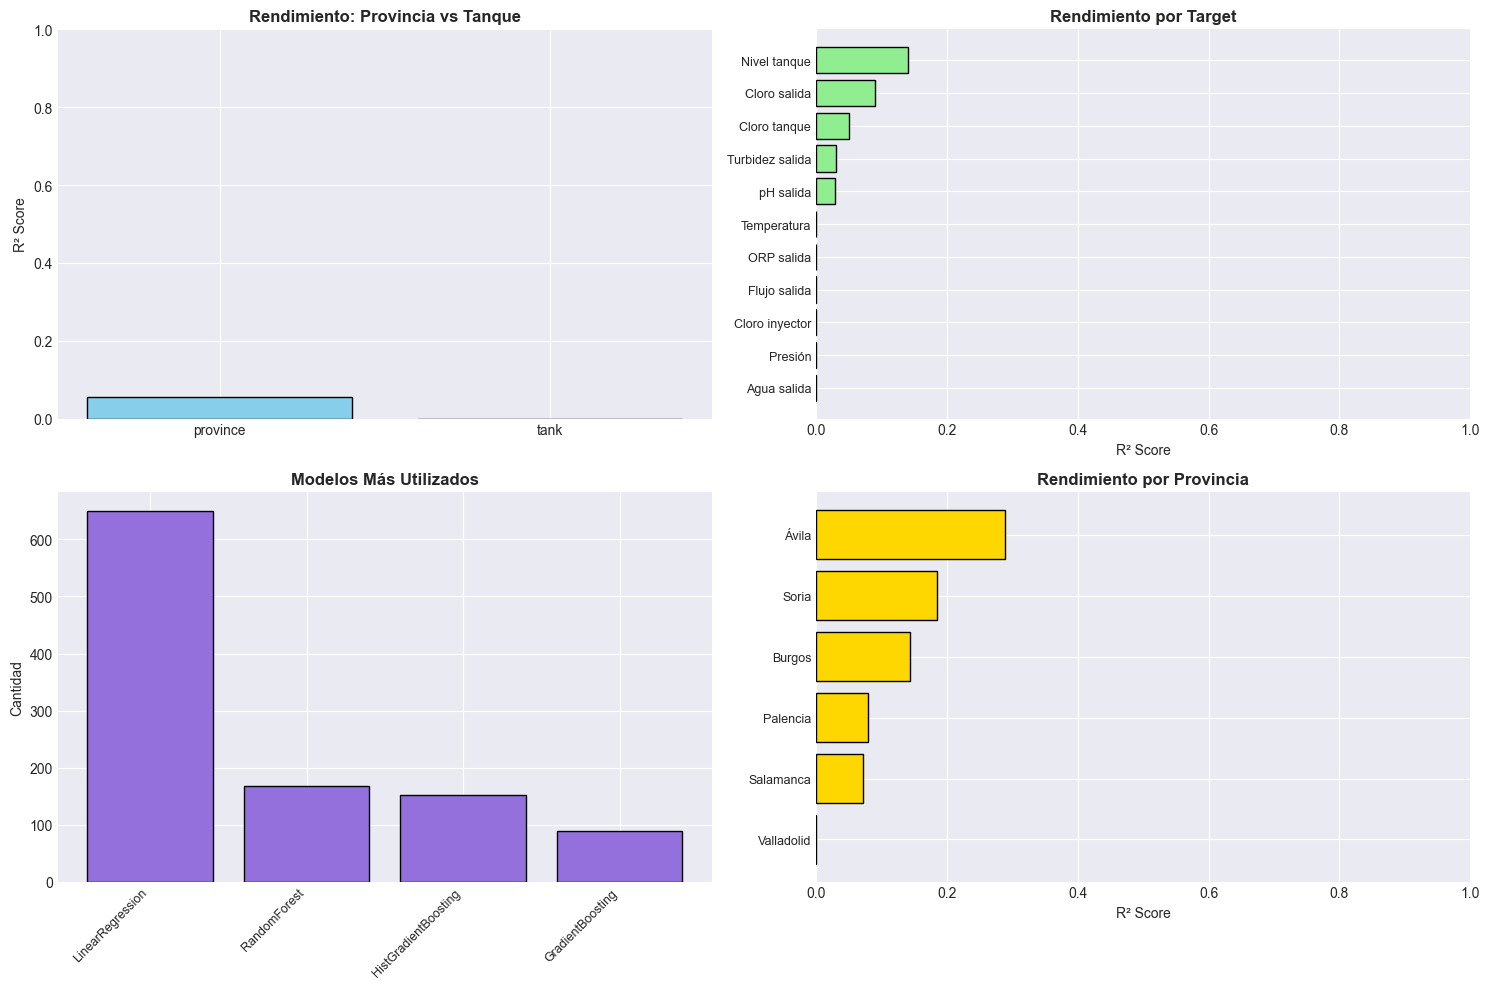

In [23]:
# ============= RESUMEN GLOBAL =============
print("\n" + "="*80)
print("📊 RESUMEN GLOBAL DE ENTRENAMIENTO")
print("="*80)

summary_df = pd.DataFrame(training_summary)

if len(summary_df) > 0:
    print(f"\n✅ Total modelos entrenados: {len(summary_df)}")
    
    # Por scope
    scope_counts = summary_df['scope_type'].value_counts()
    print(f"\n📊 Por alcance:")
    print(f"  • Provinciales: {scope_counts.get('province', 0)}")
    print(f"  • Por tanque: {scope_counts.get('tank', 0)}")
    
    print(f"\n📍 Provincias: {summary_df['province'].nunique()}")
    print(f"🏭 Tanques únicos: {summary_df[summary_df['scope_type']=='tank']['tank_id'].nunique()}")
    print(f"🎯 Targets: {summary_df['target'].nunique()}")
    
    # Comparación provincia vs tanque
    print("\n🔍 COMPARACIÓN PROVINCIA VS TANQUE (R² promedio):")
    comparison = summary_df.groupby(['scope_type', 'target'])['test_r2'].mean().unstack(fill_value=0)
    display(comparison.round(4))
    
    # Top modelos
    print("\n🏆 TOP 10 MEJORES MODELOS:")
    top_models = summary_df.nlargest(10, 'test_r2')[
        ['scope_type', 'province', 'tank_id', 'target_name', 'model_name', 'test_r2', 'test_mae']
    ]
    display(top_models.round(4))
    
    # Guardar resumen
    summary_path = MODELS_DIR / "training_summary.json"
    summary_df.to_json(summary_path, orient='records', indent=2)
    print(f"\n💾 Resumen guardado: {summary_path}")
    
    # Visualización
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # R² por scope
    scope_r2 = summary_df.groupby('scope_type')['test_r2'].mean()
    axes[0, 0].bar(scope_r2.index, scope_r2.values, color=['skyblue', 'coral'], edgecolor='black')
    axes[0, 0].set_ylabel('R² Score')
    axes[0, 0].set_title('Rendimiento: Provincia vs Tanque', fontweight='bold')
    axes[0, 0].set_ylim(0, 1)
    
    # R² por target
    target_r2 = summary_df.groupby('target_name')['test_r2'].mean().sort_values()
    axes[0, 1].barh(range(len(target_r2)), target_r2.values, color='lightgreen', edgecolor='black')
    axes[0, 1].set_yticks(range(len(target_r2)))
    axes[0, 1].set_yticklabels(target_r2.index, fontsize=9)
    axes[0, 1].set_xlabel('R² Score')
    axes[0, 1].set_title('Rendimiento por Target', fontweight='bold')
    axes[0, 1].set_xlim(0, 1)
    
    # Distribución de modelos
    model_counts = summary_df['model_name'].value_counts()
    axes[1, 0].bar(range(len(model_counts)), model_counts.values, color='mediumpurple', edgecolor='black')
    axes[1, 0].set_xticks(range(len(model_counts)))
    axes[1, 0].set_xticklabels(model_counts.index, rotation=45, ha='right', fontsize=9)
    axes[1, 0].set_ylabel('Cantidad')
    axes[1, 0].set_title('Modelos Más Utilizados', fontweight='bold')
    
    # Distribución R² por provincia
    province_r2 = summary_df.groupby('province')['test_r2'].mean().sort_values()
    axes[1, 1].barh(range(len(province_r2)), province_r2.values, color='gold', edgecolor='black')
    axes[1, 1].set_yticks(range(len(province_r2)))
    axes[1, 1].set_yticklabels(province_r2.index, fontsize=9)
    axes[1, 1].set_xlabel('R² Score')
    axes[1, 1].set_title('Rendimiento por Provincia', fontweight='bold')
    axes[1, 1].set_xlim(0, 1)
    
    plt.tight_layout()
    plt.show()

In [24]:
# ============= FUNCIÓN DE PREDICCIÓN INTELIGENTE =============
def predict_watertank(
    province: str,
    target: str,
    features: Dict[str, float],
    tank_id: Optional[str] = None,
    prefer_tank_model: bool = True
) -> Dict:
    """
    Realiza predicción inteligente con fallback automático
    
    Args:
        province: Provincia del tanque
        target: Magnitud a predecir
        features: Dict con valores de features
        tank_id: ID del tanque (opcional)
        prefer_tank_model: Si True, intenta usar modelo de tanque primero
    
    Returns:
        Dict con predicción y metadata
    """
    
    def load_and_predict(model_dir, target, features, metadata_prefix="metadata"):
        """Helper para cargar modelo y predecir"""
        try:
            metadata_path = model_dir / f"{metadata_prefix}_{target}.json"
            
            if not metadata_path.exists():
                return None
            
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
            
            model = joblib.load(Path(metadata['model_path']))
            
            scaler = None
            if metadata['use_scaling'] and metadata['scaler_path']:
                scaler = joblib.load(Path(metadata['scaler_path']))
            
            feature_values = [features.get(f, 0) for f in metadata['features']]
            X = np.array(feature_values).reshape(1, -1)
            
            if scaler:
                X = scaler.transform(X)
            
            prediction = model.predict(X)[0]
            
            return {
                'prediction': float(prediction),
                'model_scope': metadata['scope_type'],
                'province': metadata['province'],
                'tank_id': metadata.get('tank_id'),
                'target': target,
                'target_name': metadata['target_name'],
                'target_unit': metadata['target_unit'],
                'model_name': metadata['model_name'],
                'model_r2': metadata['test_r2'],
                'model_mae': metadata['test_mae']
            }
        except Exception as e:
            return None
    
    # Estrategia de predicción con fallback
    result = None
    
    # 1. Intentar modelo específico de tanque (si se proporciona tank_id y se prefiere)
    if tank_id and prefer_tank_model:
        tank_dir = MODELS_DIR / province / "tanks" / tank_id
        if tank_dir.exists():
            result = load_and_predict(tank_dir, target, features)
            if result:
                result['fallback_used'] = False
                return {**result, 'status': 'success'}
    
    # 2. Fallback a modelo provincial
    province_dir = MODELS_DIR / province / "province"
    if province_dir.exists():
        result = load_and_predict(province_dir, target, features)
        if result:
            result['fallback_used'] = tank_id is not None
            return {**result, 'status': 'success'}
    
    # 3. Intentar modelo de tanque si no se intentó antes
    if tank_id and not prefer_tank_model:
        tank_dir = MODELS_DIR / province / "tanks" / tank_id
        if tank_dir.exists():
            result = load_and_predict(tank_dir, target, features)
            if result:
                result['fallback_used'] = False
                return {**result, 'status': 'success'}
    
    return {
        'status': 'error',
        'message': f'No se encontró modelo para {province}/{target}' + (f'/{tank_id}' if tank_id else '')
    }

In [25]:
# ============= TESTS DE LA FUNCIÓN =============
if len(summary_df) > 0:
    print("\n🧪 TESTS DE PREDICCIÓN:")
    print("="*80)
    
    # Test 1: Predicción con modelo de tanque
    tank_model = summary_df[summary_df['scope_type'] == 'tank'].iloc[0] if (summary_df['scope_type'] == 'tank').any() else None
    if tank_model is not None:
        test_features = {col: 1.0 for col in feature_cols}
        result1 = predict_watertank(
            tank_model['province'],
            tank_model['target'],
            test_features,
            tank_id=tank_model['tank_id']
        )
        print("\n1️⃣ TEST MODELO DE TANQUE:")
        print(json.dumps(result1, indent=2))
    
    # Test 2: Predicción con modelo provincial
    prov_model = summary_df[summary_df['scope_type'] == 'province'].iloc[0]
    test_features = {col: 1.0 for col in feature_cols}
    result2 = predict_watertank(
        prov_model['province'],
        prov_model['target'],
        test_features
    )
    print("\n2️⃣ TEST MODELO PROVINCIAL:")
    print(json.dumps(result2, indent=2))
    
    # Test 3: Fallback automático
    if tank_model is not None:
        result3 = predict_watertank(
            tank_model['province'],
            prov_model['target'],
            test_features,
            tank_id=tank_model['tank_id']
        )
        print("\n3️⃣ TEST FALLBACK (tanque → provincia):")
        print(json.dumps(result3, indent=2))


🧪 TESTS DE PREDICCIÓN:

1️⃣ TEST MODELO DE TANQUE:
{
  "prediction": 150.0,
  "model_scope": "tank",
  "province": "Burgos",
  "tank_id": "BU_BARON_AGU_0001",
  "target": "watertanklevel",
  "target_name": "Nivel tanque",
  "target_unit": "cm",
  "model_name": "LinearRegression",
  "model_r2": 1.0,
  "model_mae": 0.0,
  "fallback_used": false,
  "status": "success"
}

2️⃣ TEST MODELO PROVINCIAL:
{
  "prediction": 287.29144169670064,
  "model_scope": "province",
  "province": "Burgos",
  "tank_id": null,
  "target": "watertanklevel",
  "target_name": "Nivel tanque",
  "target_unit": "cm",
  "model_name": "GradientBoosting",
  "model_r2": 0.07173155568619816,
  "model_mae": 22.989043886554537,
  "fallback_used": false,
  "status": "success"
}

3️⃣ TEST FALLBACK (tanque → provincia):
{
  "prediction": 150.0,
  "model_scope": "tank",
  "province": "Burgos",
  "tank_id": "BU_BARON_AGU_0001",
  "target": "watertanklevel",
  "target_name": "Nivel tanque",
  "target_unit": "cm",
  "model_name

In [26]:
# ============= UTILIDADES PARA MCP =============
utility_code = '''"""
Utilidades para sistema de predicción WaterTank
Soporta predicción por provincia y por tanque individual
"""
import joblib
import json
import numpy as np
from pathlib import Path
from typing import Dict, Optional, List

MODELS_DIR = Path("models")

def get_available_models() -> Dict:
    """Retorna modelos disponibles por provincia, tanque y target"""
    available = {
        'provinces': {},
        'tanks': {}
    }
    
    for province_dir in MODELS_DIR.iterdir():
        if not province_dir.is_dir():
            continue
        
        province = province_dir.name
        
        # Modelos provinciales
        prov_model_dir = province_dir / "province"
        if prov_model_dir.exists():
            available['provinces'][province] = {}
            for metadata_file in prov_model_dir.glob("metadata_*.json"):
                with open(metadata_file, 'r') as f:
                    meta = json.load(f)
                available['provinces'][province][meta['target']] = {
                    'model': meta['model_name'],
                    'r2': meta['test_r2'],
                    'mae': meta['test_mae']
                }
        
        # Modelos por tanque
        tanks_dir = province_dir / "tanks"
        if tanks_dir.exists():
            for tank_dir in tanks_dir.iterdir():
                if not tank_dir.is_dir():
                    continue
                
                tank_id = tank_dir.name
                tank_key = f"{province}/{tank_id}"
                available['tanks'][tank_key] = {}
                
                for metadata_file in tank_dir.glob("metadata_*.json"):
                    with open(metadata_file, 'r') as f:
                        meta = json.load(f)
                    available['tanks'][tank_key][meta['target']] = {
                        'model': meta['model_name'],
                        'r2': meta['test_r2'],
                        'mae': meta['test_mae']
                    }
    
    return available

def get_province_tanks(province: str) -> List[str]:
    """Retorna lista de tanques con modelo en una provincia"""
    tanks_dir = MODELS_DIR / province / "tanks"
    if not tanks_dir.exists():
        return []
    
    return [d.name for d in tanks_dir.iterdir() if d.is_dir()]

def get_tank_cluster(province: str, tank_id: str) -> Optional[int]:
    """Retorna el cluster asignado a un tanque"""
    try:
        cluster_dir = MODELS_DIR / province / "clustering"
        assignments_path = cluster_dir / "tank_cluster_assignments.csv"
        
        if not assignments_path.exists():
            return None
        
        import pandas as pd
        assignments = pd.read_csv(assignments_path)
        result = assignments[assignments['entityid'] == tank_id]
        
        if len(result) > 0:
            return int(result['cluster'].values[0])
        return None
    except:
        return None

def predict_watertank(
    province: str,
    target: str,
    features: Dict[str, float],
    tank_id: Optional[str] = None,
    prefer_tank_model: bool = True
) -> Dict:
    """
    Predicción inteligente con fallback automático
    
    Args:
        province: Provincia del tanque
        target: Magnitud a predecir
        features: Valores de features
        tank_id: ID del tanque (opcional)
        prefer_tank_model: Preferir modelo de tanque si existe
    
    Returns:
        Dict con predicción y metadata
        - status: 'success' o 'error'
        - prediction: Valor predicho
        - model_scope: 'tank' o 'province'
        - fallback_used: True si usó modelo provincial por fallback
    """
    
    def load_and_predict(model_dir, target, features):
        try:
            metadata_path = model_dir / f"metadata_{target}.json"
            if not metadata_path.exists():
                return None
            
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
            
            model = joblib.load(Path(metadata['model_path']))
            
            scaler = None
            if metadata['use_scaling'] and metadata['scaler_path']:
                scaler = joblib.load(Path(metadata['scaler_path']))
            
            feature_values = [features.get(f, 0) for f in metadata['features']]
            X = np.array(feature_values).reshape(1, -1)
            
            if scaler:
                X = scaler.transform(X)
            
            prediction = model.predict(X)[0]
            
            return {
                'prediction': float(prediction),
                'model_scope': metadata['scope_type'],
                'province': metadata['province'],
                'tank_id': metadata.get('tank_id'),
                'target': target,
                'target_name': metadata['target_name'],
                'target_unit': metadata['target_unit'],
                'model_name': metadata['model_name'],
                'model_r2': metadata['test_r2'],
                'model_mae': metadata['test_mae']
            }
        except Exception:
            return None
    
    result = None
    
    # Obtener cluster del tanque
    tank_cluster = None
    if tank_id:
        tank_cluster = get_tank_cluster(province, tank_id)
    
    # 1. Modelo de tanque (si disponible y preferido)
    if tank_id and prefer_tank_model:
        tank_dir = MODELS_DIR / province / "tanks" / tank_id
        if tank_dir.exists():
            result = load_and_predict(tank_dir, target, features)
            if result:
                result['fallback_used'] = False
                return {**result, 'status': 'success'}
    
    # 2. Modelo provincial (fallback)
    province_dir = MODELS_DIR / province / "province"
    if province_dir.exists():
        result = load_and_predict(province_dir, target, features)
        if result:
            result['fallback_used'] = tank_id is not None
            return {**result, 'status': 'success'}
    
    # 3. Modelo de tanque (segunda opción)
    if tank_id and not prefer_tank_model:
        tank_dir = MODELS_DIR / province / "tanks" / tank_id
        if tank_dir.exists():
            result = load_and_predict(tank_dir, target, features)
            if result:
                result['fallback_used'] = False
                return {**result, 'status': 'success'}
    
    return {
        'status': 'error',
        'message': f'Modelo no encontrado: {province}/{target}' + 
                   (f'/{tank_id}' if tank_id else '')
    }

# Ejemplo de uso en MCP:
# 
# from watertank_utils import predict_watertank, get_available_models
# 
# # Listar modelos disponibles
# models = get_available_models()
# print(f"Provincias: {list(models['provinces'].keys())}")
# print(f"Tanques: {list(models['tanks'].keys())}")
# 
# # Predicción específica de tanque
# result = predict_watertank(
#     province='Madrid',
#     target='watertanklevelpercentage',
#     features={'temperature': 15.5, 'pressurelevel': 2.1},
#     tank_id='TANK_001'
# )
# print(f"Nivel predicho: {result['prediction']}%")
# print(f"Modelo usado: {result['model_scope']}")
'''

utils_path = MODELS_DIR / "watertank_utils.py"
with open(utils_path, 'w') as f:
    f.write(utility_code)

print(f"\n💾 Utilidades guardadas: {utils_path}")


💾 Utilidades guardadas: ..\models\watertank_utils.py


In [29]:
print("\n" + "="*80)
print("✅ PROCESO COMPLETADO")
print("="*80)

# Calcular valores antes del f-string
r2_provincial = summary_df[summary_df['scope_type']=='province']['test_r2'].mean()
tank_data = summary_df[summary_df['scope_type']=='tank']
r2_tank = tank_data['test_r2'].mean() if len(tank_data) > 0 else 0.0

print(f"""
📊 RESUMEN FINAL:
  • Total modelos: {len(summary_df)}
    - Provinciales: {len(summary_df[summary_df['scope_type'] == 'province'])}
    - Por tanque: {len(summary_df[summary_df['scope_type'] == 'tank'])}
  
  • Provincias: {summary_df['province'].nunique()}
  • Tanques únicos: {summary_df[summary_df['scope_type']=='tank']['tank_id'].nunique()}
  • Targets: {summary_df['target'].nunique()}
  
  • R² promedio provincial: {r2_provincial:.4f}
  • R² promedio tanque: {r2_tank:.4f}

📁 ESTRUCTURA DE ARCHIVOS:
  models/
  ├── [provincia]/
  │   ├── province/              # Modelos provinciales
  │   │   ├── [modelo]_[target].pkl
  │   │   ├── scaler_[target].pkl
  │   │   └── metadata_[target].json
  │   └── tanks/                 # Modelos por tanque
  │       └── [tank_id]/
  │           ├── [modelo]_[target].pkl
  │           ├── scaler_[target].pkl
  │           └── metadata_[target].json
  ├── training_summary.json
  ├── models_index.json
  └── watertank_utils.py

🔧 USO EN MCP:
  from watertank_utils import predict_watertank
  
  # Predicción con modelo de tanque (fallback a provincial si no existe)
  result = predict_watertank(
      province='Madrid',
      target='watertanklevelpercentage',
      features={{'temperature': 15.5, 'pressurelevel': 2.1, ...}},
      tank_id='TANK_001'
  )
  
  print(f"Predicción: {{result['prediction']}} {{result['target_unit']}}")
  print(f"Modelo: {{result['model_scope']}} ({{result['model_name']}})")
  print(f"Fallback usado: {{result['fallback_used']}}")
""")


✅ PROCESO COMPLETADO

📊 RESUMEN FINAL:
  • Total modelos: 1056
    - Provinciales: 66
    - Por tanque: 990

  • Provincias: 6
  • Tanques únicos: 90
  • Targets: 11

  • R² promedio provincial: 0.0551
  • R² promedio tanque: -28060868775126849552384.0000

📁 ESTRUCTURA DE ARCHIVOS:
  models/
  ├── [provincia]/
  │   ├── province/              # Modelos provinciales
  │   │   ├── [modelo]_[target].pkl
  │   │   ├── scaler_[target].pkl
  │   │   └── metadata_[target].json
  │   └── tanks/                 # Modelos por tanque
  │       └── [tank_id]/
  │           ├── [modelo]_[target].pkl
  │           ├── scaler_[target].pkl
  │           └── metadata_[target].json
  ├── training_summary.json
  ├── models_index.json
  └── watertank_utils.py

🔧 USO EN MCP:
  from watertank_utils import predict_watertank

  # Predicción con modelo de tanque (fallback a provincial si no existe)
  result = predict_watertank(
      province='Madrid',
      target='watertanklevelpercentage',
      features={